In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:

# load in the dataset into a pandas dataframe, print statistics
file_path = r'c:\Users\sarah\OneDrive\Desktop\pfe\raw\members\member_week_fixed.xlsx'
df = pd.read_excel(file_path)

df.head()

,ID,Username,Firstname,Lastname,Duration,Usage,Ord.& Trans.,USB Data,Total Amount
0,NaN,NaN,Awad,Mahdi,13 h 16 min,"106,15 TND","0,00 TND","0,00 TND","106,15 TND"
1,NaN,NaN,Aziz,Ayari,3 h 32 min,"25,75 TND","0,00 TND","0,00 TND","25,75 TND"
2,NaN,NaN,Helmi,Chermiti,3 h 28 min,"25,07 TND","0,00 TND","0,00 TND","25,07 TND"
3,NaN,NaN,fares,fendri,2 h 56 min,"23,47 TND","0,00 TND","0,00 TND","23,47 TND"
4,NaN,NaN,khalil,hannachi,2 h 28 min,"16,94 TND","0,00 TND","0,00 TND","16,94 TND"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            2 non-null      object 
 1   Username      0 non-null      float64
 2   Firstname     5 non-null      object 
 3   Lastname      5 non-null      object 
 4   Duration      6 non-null      object 
 5   Usage         6 non-null      object 
 6   Ord.& Trans.  6 non-null      object 
 7   USB Data      6 non-null      object 
 8   Total Amount  6 non-null      object 
dtypes: float64(1), object(8)
memory usage: 708.0+ bytes


In [5]:
df.columns

Index(['ID', 'Username', 'Firstname', 'Lastname', 'Duration', 'Usage',
       'Ord.& Trans.', 'USB Data', 'Total Amount'],
      dtype='object')

## Dataset Structure

The dataset contains records related to **members and their activity during a specific week**.

Each row represents a **member record or activity entry**, containing information about system usage and possible financial activity.

The dataset appears to be exported from a **member activity report or management system**.

---

## Data Quality Observations

During the initial loading of the dataset, some columns may appear as **Unnamed** due to formatting spaces in the Excel report.

Additionally, some rows may contain **missing values (NaN)** or formatting artifacts such as repeated headers.

These issues require cleaning before performing analysis.

---

## Main Features of Interest

The main features of interest include:

- **Member information** – to identify individual members
- **Activity metrics** – to analyze how members interact with the system
- **Financial or usage variables** – to understand engagement levels

---

## Possible Analysis Questions

1. Which members appear most frequently in the dataset?
2. Which members show the highest activity levels?
3. Are there patterns in member activity during the week?
4. Do certain members generate more usage or value than others?

In [14]:
#Remove formatting columns
df_clean = df.loc[:, ~df.columns.str.contains('Unnamed')]
df_clean = df.dropna(axis=1, how='all')
df_clean = df_clean.drop(columns=['ID'])

In [15]:
#remove empty rows
df_clean = df_clean.dropna(how='all')

In [16]:
#reset index
df_clean.reset_index(drop=True, inplace=True)

In [17]:
#inspect cleaned data set
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Firstname     5 non-null      object
 1   Lastname      5 non-null      object
 2   Duration      6 non-null      object
 3   Usage         6 non-null      object
 4   Ord.& Trans.  6 non-null      object
 5   USB Data      6 non-null      object
 6   Total Amount  6 non-null      object
dtypes: object(7)
memory usage: 468.0+ bytes


,Firstname,Lastname,Duration,Usage,Ord.& Trans.,USB Data,Total Amount
0,Awad,Mahdi,13 h 16 min,"106,15 TND","0,00 TND","0,00 TND","106,15 TND"
1,Aziz,Ayari,3 h 32 min,"25,75 TND","0,00 TND","0,00 TND","25,75 TND"
2,Helmi,Chermiti,3 h 28 min,"25,07 TND","0,00 TND","0,00 TND","25,07 TND"
3,fares,fendri,2 h 56 min,"23,47 TND","0,00 TND","0,00 TND","23,47 TND"
4,khalil,hannachi,2 h 28 min,"16,94 TND","0,00 TND","0,00 TND","16,94 TND"


In [18]:
# remove rows where first or last name is missing
df_clean = df_clean.dropna(subset=['Firstname', 'Lastname'])

In [19]:
# reset index after removing rows
df_clean.reset_index(drop=True, inplace=True)

In [20]:
# clean Usage column
df_clean['Usage'] = (
    df_clean['Usage']
    .str.replace(' TND', '')
    .str.replace(',', '.')
    .astype(float)
)

In [21]:
# clean other monetary columns
df_clean['Ord.& Trans.'] = (
    df_clean['Ord.& Trans.']
    .str.replace(' TND', '')
    .str.replace(',', '.')
    .astype(float)
)

df_clean['USB Data'] = (
    df_clean['USB Data']
    .str.replace(' TND', '')
    .str.replace(',', '.')
    .astype(float)
)

df_clean['Total Amount'] = (
    df_clean['Total Amount']
    .str.replace(' TND', '')
    .str.replace(',', '.')
    .astype(float)
)

In [22]:
# extract hours and minutes from duration
import re

def duration_to_minutes(duration):
    if pd.isna(duration):
        return None
    hours = re.search(r'(\d+)\s*h', duration)
    minutes = re.search(r'(\d+)\s*min', duration)
    
    h = int(hours.group(1)) if hours else 0
    m = int(minutes.group(1)) if minutes else 0
    
    return h*60 + m

df_clean['Duration_minutes'] = df_clean['Duration'].apply(duration_to_minutes)

In [23]:
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Firstname         5 non-null      object 
 1   Lastname          5 non-null      object 
 2   Duration          5 non-null      object 
 3   Usage             5 non-null      float64
 4   Ord.& Trans.      5 non-null      float64
 5   USB Data          5 non-null      float64
 6   Total Amount      5 non-null      float64
 7   Duration_minutes  5 non-null      int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 452.0+ bytes


,Firstname,Lastname,Duration,Usage,Ord.& Trans.,USB Data,Total Amount,Duration_minutes
0,Awad,Mahdi,13 h 16 min,106.15,0.0,0.0,106.15,796
1,Aziz,Ayari,3 h 32 min,25.75,0.0,0.0,25.75,212
2,Helmi,Chermiti,3 h 28 min,25.07,0.0,0.0,25.07,208
3,fares,fendri,2 h 56 min,23.47,0.0,0.0,23.47,176
4,khalil,hannachi,2 h 28 min,16.94,0.0,0.0,16.94,148


## Exploratory Data Analysis

After cleaning and preparing the dataset, we will focus on analyzing **member activity, session duration, and financial usage**.

The analysis will explore the following aspects:

- **Member activity frequency** – to identify the most active members.
- **Session duration distribution** – to understand how long sessions typically last.
- **Usage and financial metrics** – to analyze how much value members generate.
- **Transaction-related metrics** – to observe how orders or transfers contribute to total amounts.

Through these visualizations, we aim to gain insight into **member behavior and system usage during the recorded period**.

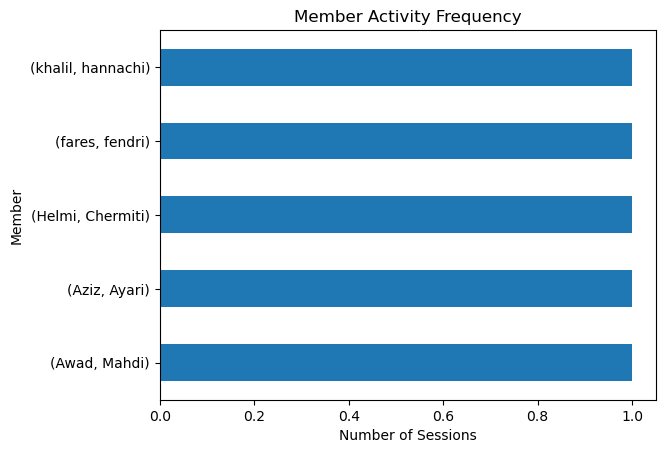

In [25]:
# number of appearances per member
member_activity = df_clean.groupby(['Firstname','Lastname']).size()

member_activity.sort_values().plot(kind='barh')

plt.title("Member Activity Frequency")
plt.xlabel("Number of Sessions")
plt.ylabel("Member")
plt.show()

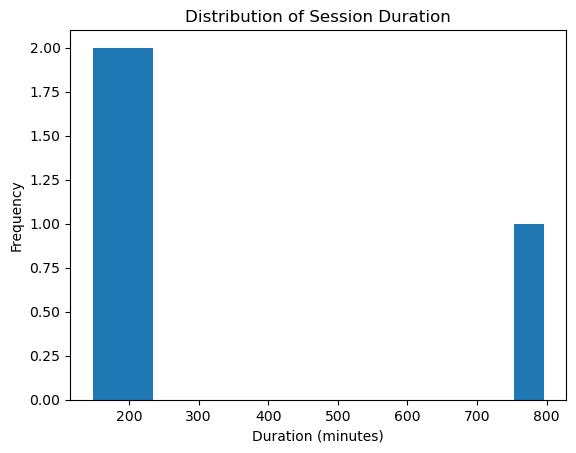

In [26]:
# distribution of session durations
df_clean['Duration_minutes'].plot(kind='hist', bins=15)

plt.title("Distribution of Session Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

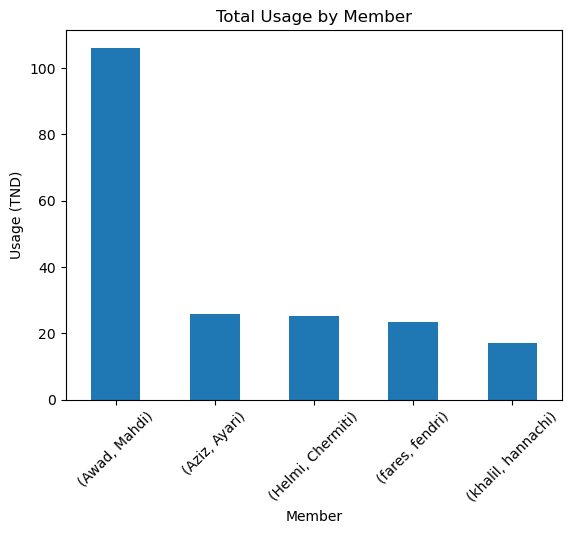

In [27]:
usage_by_member = df_clean.groupby(['Firstname','Lastname'])['Usage'].sum()

usage_by_member.plot(kind='bar')

plt.title("Total Usage by Member")
plt.xlabel("Member")
plt.ylabel("Usage (TND)")
plt.xticks(rotation=45)
plt.show()

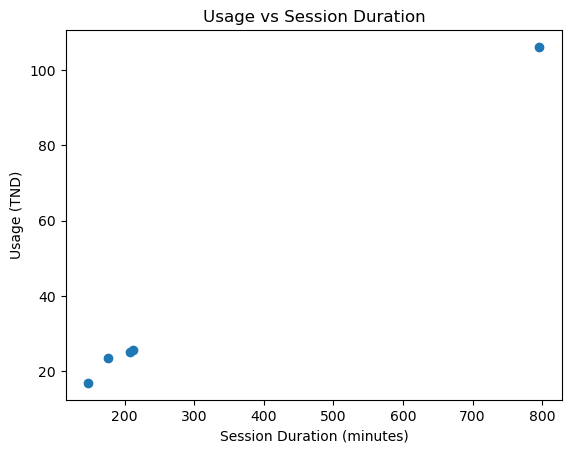

In [28]:
#usage vs duration 
plt.scatter(df_clean['Duration_minutes'], df_clean['Usage'])

plt.title("Usage vs Session Duration")
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Usage (TND)")
plt.show()